# Ôn tập metrics — Lab 21

YOLO sinh bounding box và confidence của từng ảnh. Tracker liên kết đối tượng qua thời gian để gán ID; box YOLO không tự có tracking ID.

IoU = diện tích giao / diện tích hợp. `--iou` điều khiển NMS detector, không phải association threshold của tracker. Dùng nhánh one-to-many của YOLO26 để NMS có ý nghĩa.

$MOTA=1-(FN+FP+IDSW)/GT$; MOTA có thể âm.

$IDF1=2IDTP/(2IDTP+IDFP+IDFN)$.

$HOTA_\alpha=\sqrt{DetA_\alpha AssA_\alpha}$, sau đó lấy trung bình qua các ngưỡng alpha. HOTA không phải trung bình MOTA và IDF1.

1. “YOLO box tự có tracking ID” — **Sai**: cần liên kết thời gian.
2. “`--iou` là ngưỡng ghép tracker” — **Sai**: đây là NMS detector.
3. “HOTA xét detection và association” — **Đúng**: DetA và AssA cùng đóng góp.


In [1]:
from lab21.metrics import box_iou
assert box_iou([0,0,2,2],[0,0,2,2]) == 1
assert box_iou([0,0,1,1],[2,2,3,3]) == 0
assert box_iou([0,0,0,0],[0,0,0,0]) == 0
print("IoU edge cases passed")

IoU edge cases passed


Matplotlib is building the font cache; this may take a moment.


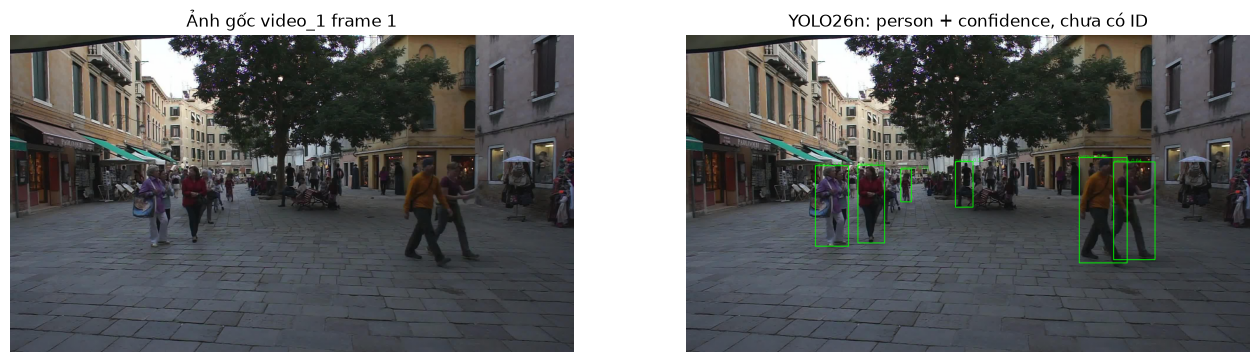

6 person detections; device=mps


In [2]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from lab21.dataset import frames
from lab21.detector import Detector
root = Path(os.environ['LAB_DATA'])
p = frames(root/'video_1'/'img1')[0]
img = cv2.imread(str(p))
det = Detector()
boxes = det.detect(img, .30, .50)
rendered = img.copy()
for x1,y1,x2,y2,confidence,cls in boxes:
    cv2.rectangle(rendered,(int(x1),int(y1)),(int(x2),int(y2)),(0,255,0),2)
    cv2.putText(rendered,f'person {confidence:.2f}',(int(x1),int(y1)),cv2.FONT_HERSHEY_SIMPLEX,.5,(0,255,0),1)
fig, ax=plt.subplots(1,2,figsize=(16,6))
ax[0].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB));ax[0].set_title('Ảnh gốc video_1 frame 1')
ax[1].imshow(cv2.cvtColor(rendered,cv2.COLOR_BGR2RGB));ax[1].set_title('YOLO26n: person + confidence, chưa có ID')
for a in ax: a.axis('off')
plt.show()
print(f'{len(boxes)} person detections; device={det.device}')